<a href="https://colab.research.google.com/github/Karan-Potdukhe/AI-ML-DL-Hacktoberfest2024-WB/blob/Karan-Potdukhe-patch-1/Real_Face_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout, BatchNormalization, LeakyReLU, Conv2D, Conv2DTranspose
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from PIL import Image

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load and preprocess images
def load_images(folder_path, img_size=(64, 64)):
    images = []
    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, file_name)
            img = Image.open(img_path).resize(img_size)
            img = np.array(img) / 255.0  # Normalize to [0, 1]
            images.append(img)
    return np.array(images)

In [ ]:
# Update the folder_path with your dataset's path
folder_path = "/content/drive/MyDrive/dataset/GAN/Celebrrity New Data"
images = load_images(folder_path)
print("Dataset shape:", images.shape)

Dataset shape: (1006, 64, 64, 3)


In [ ]:

# Set parameters
latent_dim = 100
img_shape = images.shape[1:]

In [ ]:
# Generator model
def build_generator(latent_dim, img_shape):
    model = Sequential()
    model.add(Dense(128 * 16 * 16, activation="relu", input_dim=latent_dim))
    model.add(Reshape((16, 16, 128)))
    model.add(Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2DTranspose(64, kernel_size=4, strides=2, padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2D(3, kernel_size=7, activation="tanh", padding="same"))
    return model

In [ ]:
# Discriminator model
def build_discriminator(img_shape):
    model = Sequential()
    model.add(Conv2D(64, kernel_size=4, strides=2, input_shape=img_shape, padding="same"))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.25))
    model.add(Conv2D(128, kernel_size=4, strides=2, padding="same"))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))
    return model

In [ ]:
# Build and compile the models
generator = build_generator(latent_dim, img_shape)
discriminator = build_discriminator(img_shape)
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

# Combined GAN model
z = Input(shape=(latent_dim,))
img = generator(z)
discriminator.trainable = False
valid = discriminator(img)
combined = Model(z, valid)
combined.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy')

In [ ]:

# Training the GAN
def train_gan(generator, discriminator, combined, images, epochs, batch_size=128):
    real = np.ones((batch_size, 1))
    fake = np.zeros((batch_size, 1))

    for epoch in range(epochs):
        # Train Discriminator
        idx = np.random.randint(0, images.shape[0], batch_size)
        real_imgs = images[idx]

        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        gen_imgs = generator.predict(noise)

        d_loss_real = discriminator.train_on_batch(real_imgs, real)
        d_loss_fake = discriminator.train_on_batch(gen_imgs, fake)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train Generator
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        g_loss = combined.train_on_batch(noise, real)

        # Print progress
        print(f"{epoch}/{epochs} [D loss: {d_loss[0]}, acc.: {100*d_loss[1]:.2f}%] [G loss: {g_loss}]")

# Train the GAN
train_gan(generator, discriminator, combined, images, epochs=10, batch_size=32)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.10/dist-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0/10 [D loss: 0.6798098087310791, acc.: 76.56%] [G loss: [array(0.6836475, dtype=float32), array(0.6836475, dtype=float32), array(0.84375, dtype=float32)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step


1/10 [D loss: 0.6890796422958374, acc.: 61.85%] [G loss: [array(0.69006944, dtype=float32), array(0.69006944, dtype=float32), array(0.5390625, dtype=float32)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
2/10 [D loss: 0.6891486644744873, acc.: 51.51%] [G loss: [array(0.69009334, dtype=float32), array(0.69009334, dtype=float32), array(0.47395834, dtype=float32)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
3/10 [D loss: 0.6900782585144043, acc.: 46.23%] [G loss: [array(0.6911511, dtype=float32), array(0.6911511, dtype=float32), array(0.43359375, dtype=float32)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
4/10 [D loss: 0.6901079416275024, acc.: 43.70%] [G loss: [array(0.69130963, dtype=float32), array(0.69130963, dtype=float32), array(0.415625, dtype=float32)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
5/10 [D loss: 0.6914777755737305, acc.: 42.33%] [G loss: [array(0.69261056, dtype=float32), array(0.69261056, dtype=float32), array(0.40625, dtype=float32)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
6/10 [D los

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step


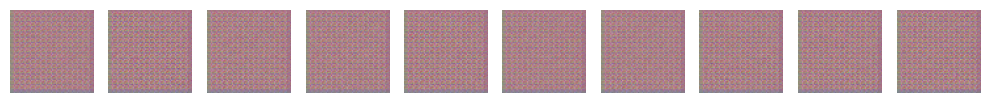

In [ ]:
import matplotlib.pyplot as plt

# Function to generate and display synthetic images
def visualize_generated_images(generator, latent_dim, examples=10, dim=(1, 10)):
    noise = np.random.normal(0, 1, (examples, latent_dim))
    generated_images = generator.predict(noise)

    # Normalize images back to [0, 1] range for visualization
    generated_images = (generated_images + 1) / 2.0

    plt.figure(figsize=(10, 2))
    for i in range(examples):
        plt.subplot(dim[0], dim[1], i + 1)
        plt.imshow(generated_images[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# After training, visualize the outputs
visualize_generated_images(generator, latent_dim, examples=10, dim=(1, 10))
